# CLO4 – AI-Powered Intrusion Detection System
**Course:** Information Security  
**Dataset:** UNSW-NB15  
**Algorithm:** Random Forest Classifier  
**Objective:** Classify network traffic as Normal or Attack using Machine Learning

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn

## Step 0 – Install & Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [4]:
# Load training and testing sets
train_df = pd.read_csv('/content/drive/MyDrive/is assignment 1/UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/is assignment 1/UNSW_NB15_testing-set.csv')

# Combine for unified preprocessing, then re-split later
df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Total records: {len(df):,}')
print(f'Features:      {df.shape[1]}')
print(f'\nClass distribution:')
print(df['label'].value_counts())

Total records: 257,673
Features:      45

Class distribution:
label
1    164673
0     93000
Name: count, dtype: int64


## Step 2 – Exploratory Data Analysis (EDA)

In [5]:
# Basic overview
print('=== Dataset Info ===')
print(df.dtypes.value_counts())
print(f'\nMissing values: {df.isnull().sum().sum()}')
df.head()

=== Dataset Info ===
int64      30
float64    11
object      4
Name: count, dtype: int64

Missing values: 0


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


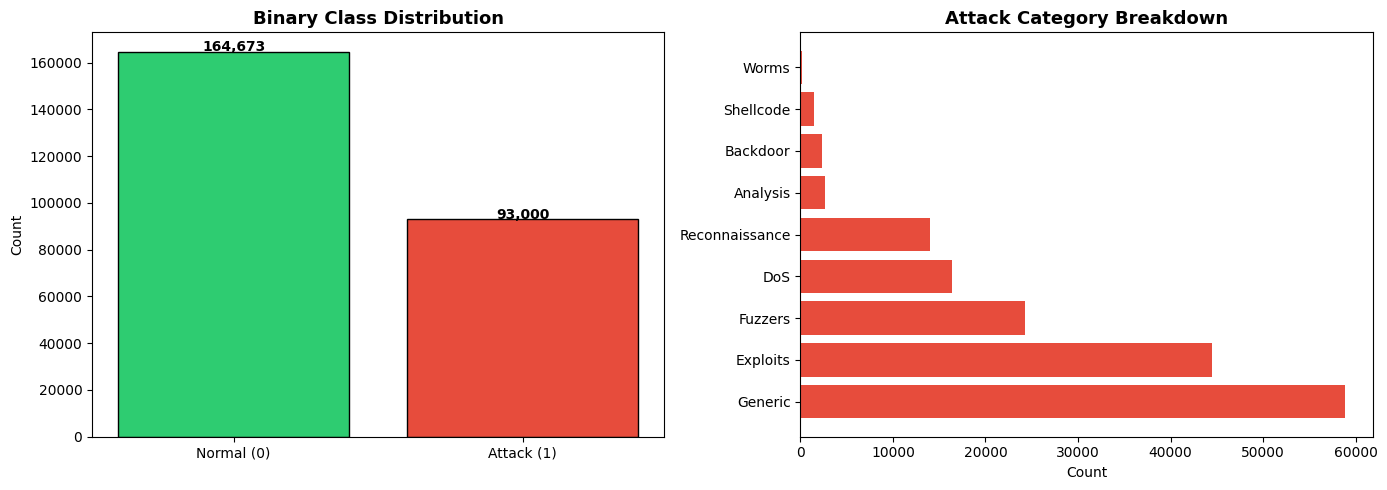

Figure saved: plot_class_distribution.png


In [6]:
# --- Plot 1: Class Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary label (0 = Normal, 1 = Attack)
label_counts = df['label'].value_counts()
axes[0].bar(['Normal (0)', 'Attack (1)'], label_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Binary Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Attack category breakdown
attack_counts = df[df['label'] == 1]['attack_cat'].value_counts()
axes[1].barh(attack_counts.index, attack_counts.values, color='#e74c3c')
axes[1].set_title('Attack Category Breakdown', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: plot_class_distribution.png')

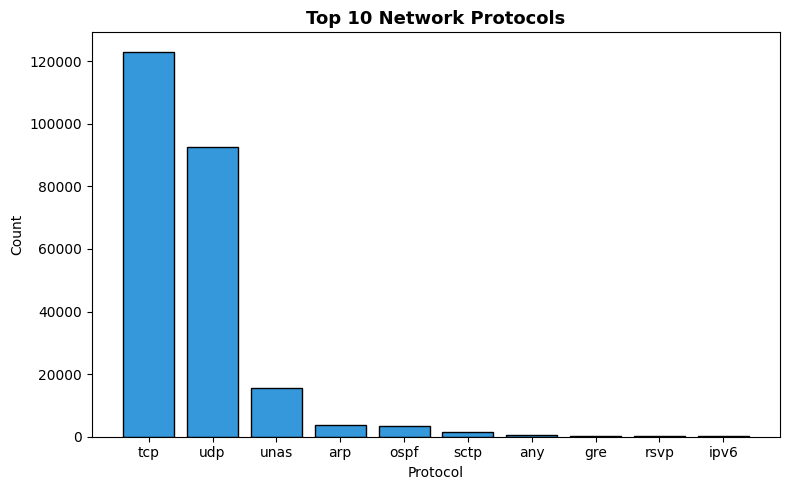

In [7]:
# --- Plot 2: Protocol Distribution ---
fig, ax = plt.subplots(figsize=(8, 5))
proto_counts = df['proto'].value_counts().head(10)
ax.bar(proto_counts.index, proto_counts.values, color='#3498db', edgecolor='black')
ax.set_title('Top 10 Network Protocols', fontsize=13, fontweight='bold')
ax.set_xlabel('Protocol')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('plot_protocol_dist.png', dpi=150, bbox_inches='tight')
plt.show()

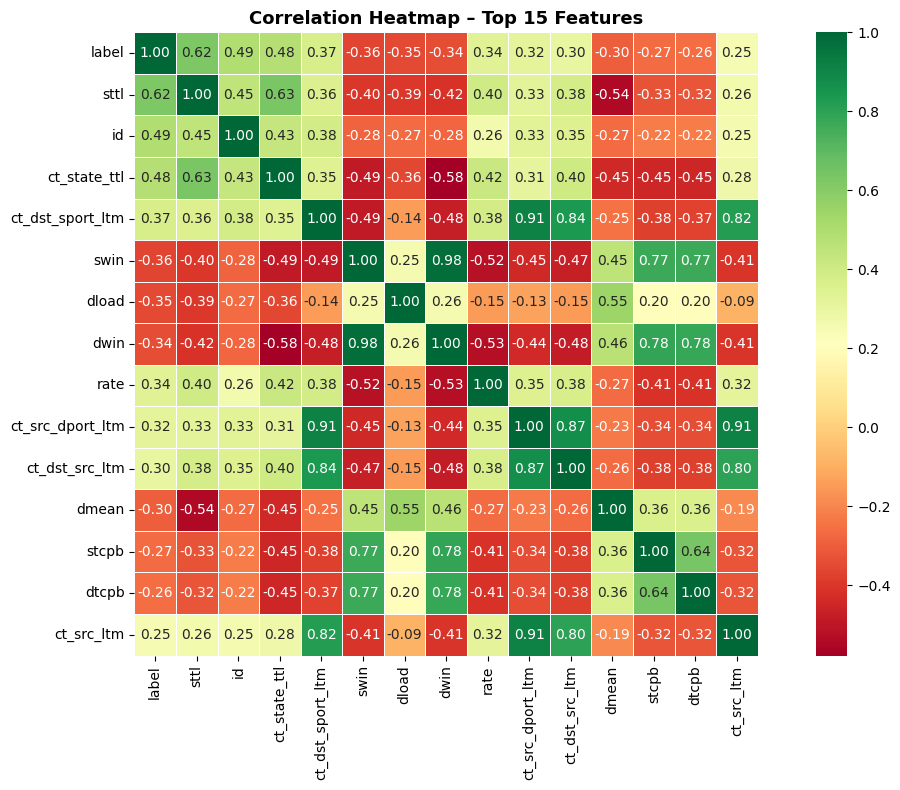

In [8]:
# --- Plot 3: Correlation Heatmap (numeric features) ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Pick top correlated features with label
corr_with_label = df[numeric_cols].corr()['label'].abs().sort_values(ascending=False)
top_features = corr_with_label.head(15).index.tolist()

plt.figure(figsize=(12, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, square=True)
plt.title('Correlation Heatmap – Top 15 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 – Data Preprocessing

In [9]:
# Drop irrelevant columns
drop_cols = ['id', 'attack_cat']  # 'id' is just a row index; 'attack_cat' leaks multi-class info
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Handle missing values
print('Missing values before fill:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Fill numeric NaN with median, categorical with mode
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

print('\nMissing values after fill:', df_clean.isnull().sum().sum())

Missing values before fill:
Series([], dtype: int64)

Missing values after fill: 0


In [10]:
# Encode categorical features (proto, service, state)
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'label']  # keep label separate

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print(f'Encoded categorical columns: {cat_cols}')

Encoded categorical columns: ['proto', 'service', 'state']


In [12]:
# Split features and target
X = df_clean.drop(columns=['label'])
y = df_clean['label']

# Normalize numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples:  {X_train.shape[0]:,}')
print(f'Testing samples:   {X_test.shape[0]:,}')
print(f'Features:          {X_train.shape[1]}')

Training samples:  206,138
Testing samples:   51,535
Features:          42


## Step 4 – Model Training (Random Forest)

**Why Random Forest?**
- Ensemble of decision trees → reduces overfitting
- Handles high-dimensional, mixed-type network data well
- Provides feature importance rankings
- Robust to outliers common in network traffic

In [13]:
# Train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 trees
    max_depth=None,        # Grow fully
    min_samples_split=5,
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

print('Training Random Forest... (may take ~30 seconds)')
rf_model.fit(X_train, y_train)
print('Training complete!')

Training Random Forest... (may take ~30 seconds)
Training complete!


## Step 5 – Model Evaluation

In [14]:
# Predictions
y_pred = rf_model.predict(X_test)

# Core metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 40)
print('     SECURITY TOOL PERFORMANCE REPORT')
print('=' * 40)
print(f'  Accuracy:  {acc:.4f} ({acc*100:.2f}%)')
print(f'  Precision: {prec:.4f}')
print(f'  Recall:    {rec:.4f}  ← Critical for IDS')
print(f'  F1 Score:  {f1:.4f}')
print('=' * 40)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

     SECURITY TOOL PERFORMANCE REPORT
  Accuracy:  0.9531 (95.31%)
  Precision: 0.9646
  Recall:    0.9618  ← Critical for IDS
  F1 Score:  0.9632

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.94      0.94     18600
      Attack       0.96      0.96      0.96     32935

    accuracy                           0.95     51535
   macro avg       0.95      0.95      0.95     51535
weighted avg       0.95      0.95      0.95     51535



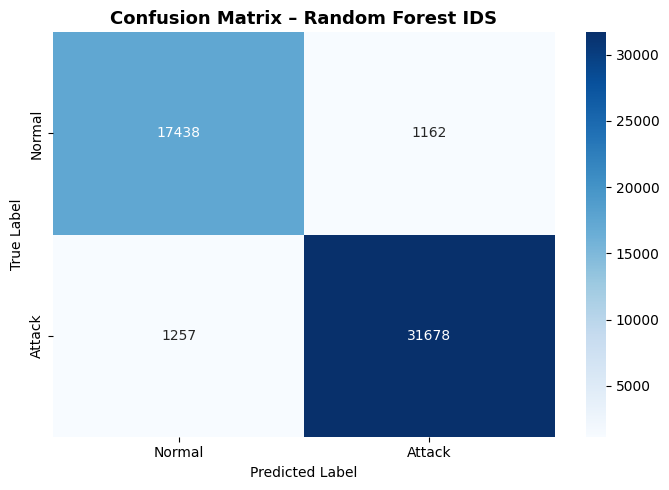

True Positives  (Attacks correctly detected): 31,678
False Negatives (Attacks missed - DANGEROUS):  1,257
False Positives (Normal flagged as attack):    1,162
True Negatives  (Normal correctly allowed):   17,438


In [15]:
# --- Plot 4: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix – Random Forest IDS', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (Attacks correctly detected): {tp:,}')
print(f'False Negatives (Attacks missed - DANGEROUS):  {fn:,}')
print(f'False Positives (Normal flagged as attack):    {fp:,}')
print(f'True Negatives  (Normal correctly allowed):   {tn:,}')

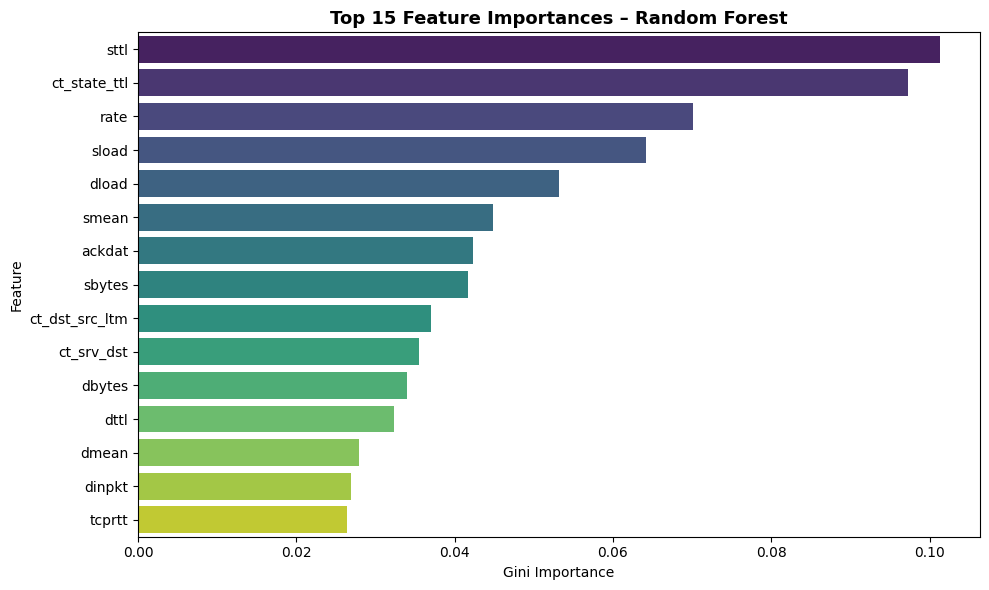

In [16]:
# --- Plot 5: Feature Importance ---
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 15 Feature Importances – Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# --- Summary Table ---
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Attack)', 'F1 Score'],
    'Value':  [f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}'],
    'Security Implication': [
        'Overall correctness of the IDS',
        'Of all flagged traffic, how much was truly malicious',
        'Of all real attacks, how many were caught (CRITICAL)',
        'Harmonic mean — balanced performance indicator'
    ]
})
print(summary.to_string(index=False))

         Metric  Value                                 Security Implication
       Accuracy 0.9531                       Overall correctness of the IDS
      Precision 0.9646 Of all flagged traffic, how much was truly malicious
Recall (Attack) 0.9618 Of all real attacks, how many were caught (CRITICAL)
       F1 Score 0.9632       Harmonic mean — balanced performance indicator
